<a href="https://colab.research.google.com/github/dwmhr12/Nike_Run_Club_Tugas/blob/main/03_nike_run_club_reviews_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-3-635782303.py:67: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_nike_reviews = pd.read_csv(file_path)


Informasi DataFrame awal:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104211 entries, 0 to 104210
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   reviewId              104211 non-null  object
 1   userName              104211 non-null  object
 2   userImage             104211 non-null  object
 3   content               104211 non-null  object
 4   score                 104211 non-null  int64 
 5   thumbsUpCount         104211 non-null  int64 
 6   reviewCreatedVersion  96609 non-null   object
 7   at                    104211 non-null  object
 8   replyContent          32 non-null      object
 9   repliedAt             32 non-null      object
 10  appVersion            96609 non-null   object
dtypes: int64(2), object(9)
memory usage: 8.7+ MB


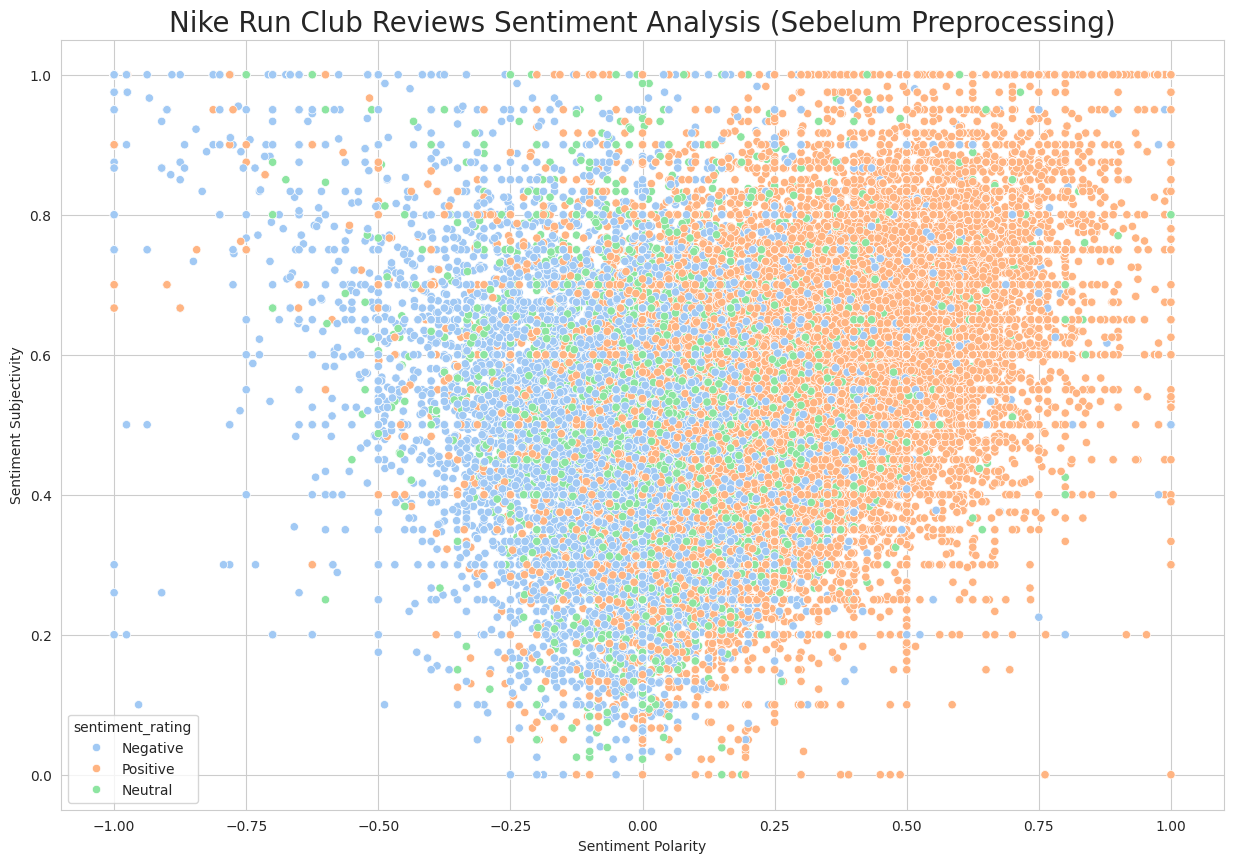


Preprocessing Data: Memahami tipe dan informasi data awal.
Kolom seperti 'reviewCreatedVersion', 'replyContent', 'repliedAt', dan 'appVersion' memiliki nilai null.
Versi Aplikasi yang Unik dalam Review:
['4.66.0' '2.9.0' nan '4.65.0' '3.13.2' '4.42.0' '4.7.1' '4.14.0' '4.10.0'
 '4.63.1' '2.6.0' '4.30.0' '4.31.0' '4.64.0' '2.2.0' '1.2.1' '1.3.0'
 '4.33.0' '2.8.0' '4.38.0' '4.34.0' '4.28.0' '4.62.0' '4.39.0' '2.7.0'
 '4.29.0' '4.36.1' '4.26.0' '4.6.0' '1.2.2' '1.4' '4.17.0' '4.40.0'
 '4.41.0' '4.37.0' '4.16.0' '4.13.0' '4.24.0' '4.19.1' '1.1.0' '4.22.0'
 '4.32.0' '4.35.0' '2.0.1' '4.15.1' '4.12.1' '2.5.0' '2.4.0' '2.3.0'
 '2.0.3' '3.2.0' '4.5.1' '4.2.2' '4.21.0' '4.36.0' '3.3.0' '4.18.0'
 '2.1.0' '3.5.1' '4.25.0' '3.0.2' '1.7.9' '4.15.2' '3.15.0' '4.20.0'
 '2.14.1' '3.11.1' '2.25.0' '4.27.0' '3.8.1' '4.4.1' '4.23.0' '1.3.4'
 '1.0.3' '2.15.2' '3.6.0' '3.7.1' '2.19.1' '4.11.0' '3.1.0' '4.9.7' '1.7'
 '4.8.0' '4.4.0' '2.13.2' '1.3.2' '2.7.1' '2.11.2' '4.15.0' '4.19.0'
 '2.20.2' '3.12.0' '3.

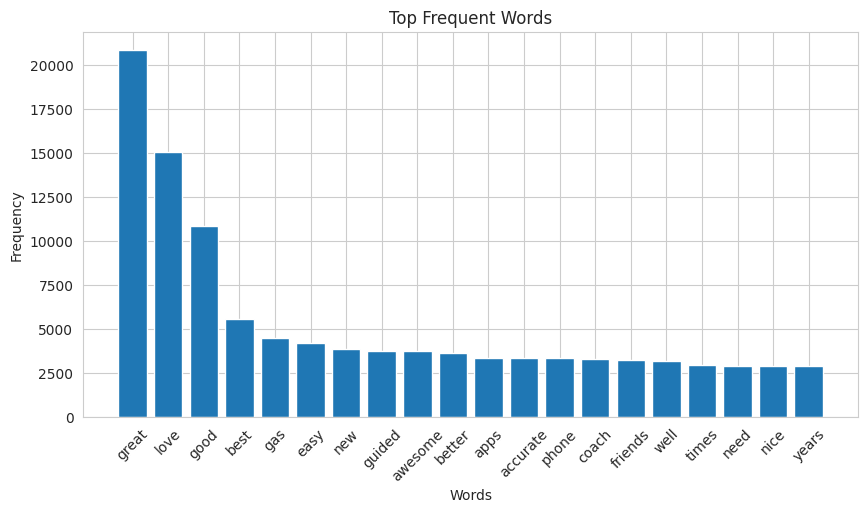


Hasil setelah lemmatization:
                                       final_cleaned  \
0  this app stops recording your run midway does ...   
1                    best run tracking app out there   
2  heart rate monitor notworking on galaxy watch ...   
3  had this app years ago and logged in to all of...   
4  why do i need to login to my account every mor...   

                                      token_after_sr  \
0    [stops, recording, midway, notby, waste, space]   
1                                             [best]   
2  [heart, rate, monitor, notworking, galaxy, wat...   
3  [years, ago, logged, old, data, lost, contacte...   
4  [need, login, account, morning, annoying, need...   

                                   lemmatized_tokens  
0     [stop, recording, midway, notby, waste, space]  
1                                             [best]  
2  [heart, rate, monitor, notworking, galaxy, wat...  
3  [year, ago, logged, old, data, lost, contacted...  
4  [need, login, acco

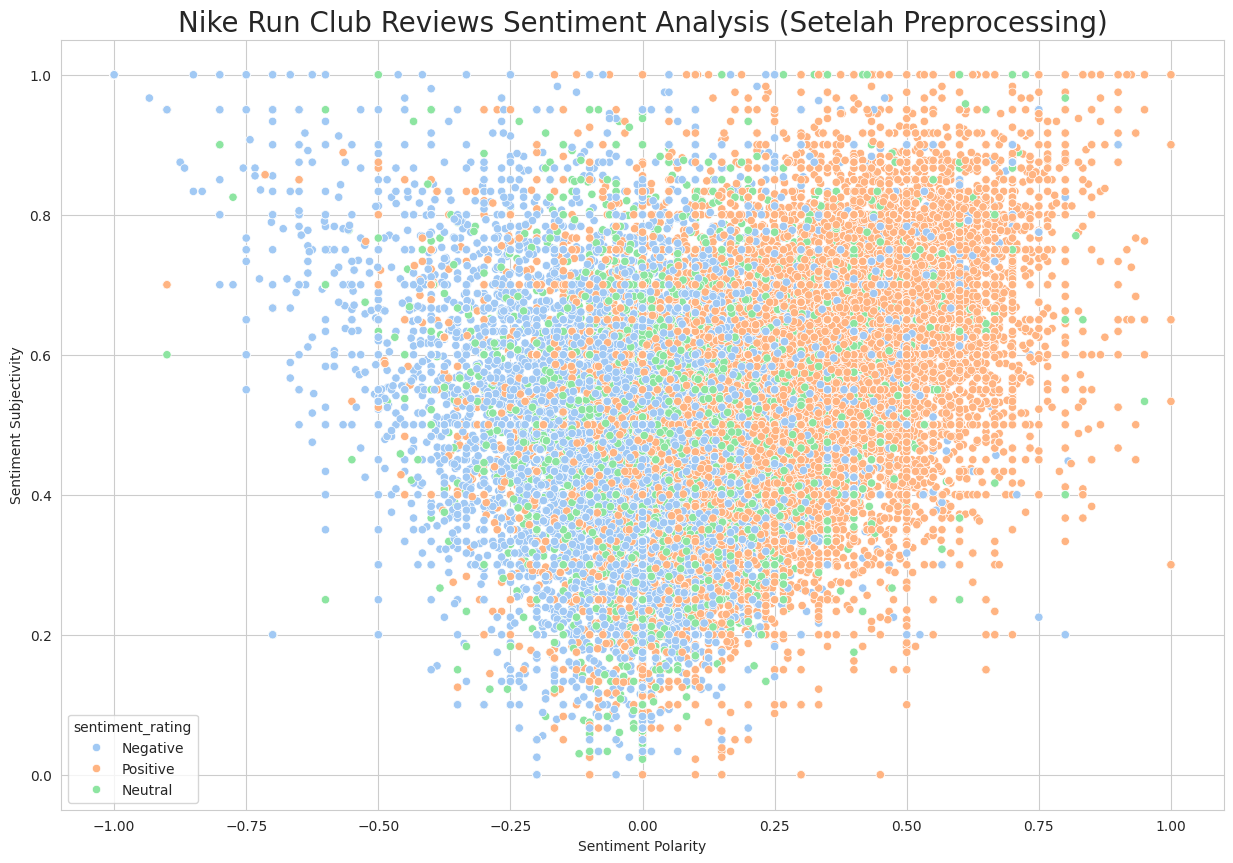

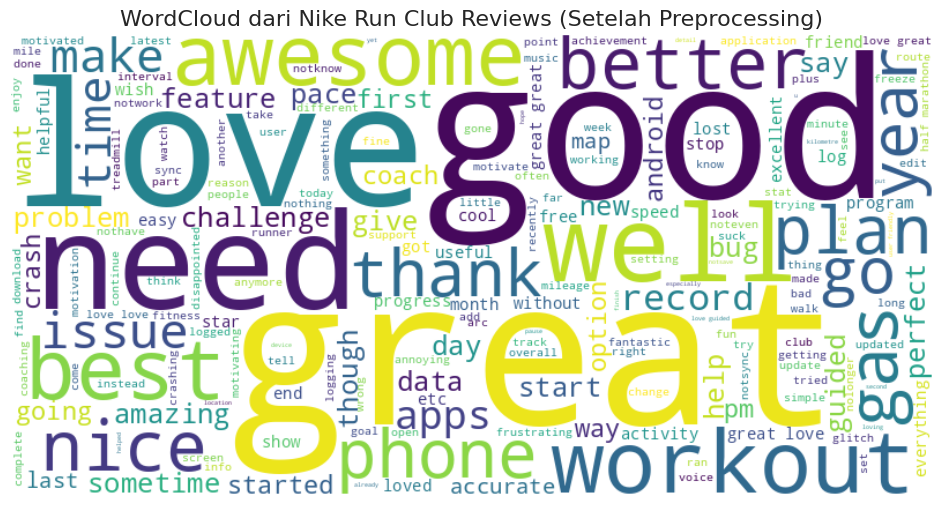


DataFrame telah disimpan ke df_nike_reviews2.csv


In [3]:
# 03-nike-run-club-reviews-data-preprocessing.ipynb
# Tujuan: Membersihkan dan mempreproses data review Nike Run Club untuk analisis sentimen dan ekstraksi fitur.
# Data input: nike_reviews.csv (dari file 02) yang berisi ~104.211 review berbahasa Inggris.

# Instalasi dan impor library
try:
    import pandas as pd
    import numpy as np
    import re
    import string
    import emoji
    import contractions
    from symspellpy import SymSpell, Verbosity
    from langdetect import detect, LangDetectException
    import pkg_resources
    import matplotlib.pyplot as plt
    import seaborn as sns
    from textblob import TextBlob
    from wordcloud import WordCloud
    import nltk
    import os
except ImportError as e:
    print(f"Error mengimpor library: {e}")
    !pip install pandas numpy emoji contractions symspellpy langdetect matplotlib seaborn textblob wordcloud nltk
    import pandas as pd
    import numpy as np
    import re
    import string
    import emoji
    import contractions
    from symspellpy import SymSpell, Verbosity
    from langdetect import detect, LangDetectException
    import pkg_resources
    import matplotlib.pyplot as plt
    import seaborn as sns
    from textblob import TextBlob
    from wordcloud import WordCloud
    import nltk
    import os

# Unduh resource NLTK yang diperlukan
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception as e:
    print(f"Error mengunduh resource NLTK: {e}")

# Impor bagian spesifik dari nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter

# Mengatur gaya visualisasi
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

# Membaca data dari file CSV
file_path = 'nike_reviews.csv'
if not os.path.exists(file_path):
    print(f"File {file_path} tidak ditemukan. Pastikan file ada di direktori yang sama atau ubah nama file.")
    exit()
else:
    df_nike_reviews = pd.read_csv(file_path)
    print("Informasi DataFrame awal:")
    df_nike_reviews.info()

    # Tambahkan kolom ID incremental
    df_nike_reviews['id'] = range(1, len(df_nike_reviews) + 1)

    # Hapus kolom yang tidak dibutuhkan
    columns_to_drop = ["reviewId", "userName", "userImage", "replyContent", "repliedAt"]
    df_nike_reviews = df_nike_reviews.drop(columns=[col for col in columns_to_drop if col in df_nike_reviews.columns])

# Polaritas Sentimen sebelum Text Preprocessing
df_nike_reviews['sentiment_polarity'] = df_nike_reviews['content'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_nike_reviews['sentiment_subjectivity'] = df_nike_reviews['content'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
df_nike_reviews['sentiment_rating'] = df_nike_reviews['score'].apply(
    lambda x: 'Positive' if x > 3 else ('Neutral' if x == 3 else 'Negative')
)
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_nike_reviews['sentiment_polarity'], y=df_nike_reviews['sentiment_subjectivity'],
                hue=df_nike_reviews['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Nike Run Club Reviews Sentiment Analysis (Sebelum Preprocessing)", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.grid(True)
plt.show()

# Preprocessing Data
print("\nPreprocessing Data: Memahami tipe dan informasi data awal.")
print("Kolom seperti 'reviewCreatedVersion', 'replyContent', 'repliedAt', dan 'appVersion' memiliki nilai null.")
# Melihat semua nilai unik dalam kolom 'reviewCreatedVersion'
unique_versions = df_nike_reviews['reviewCreatedVersion'].unique()
print("Versi Aplikasi yang Unik dalam Review:")
print(unique_versions)
num_unique_versions = df_nike_reviews['reviewCreatedVersion'].nunique()
print(f"\nJumlah versi aplikasi dalam review yang diambil adalah: {num_unique_versions}")

# Menangani nilai null
df_nike_reviews['reviewCreatedVersion'] = df_nike_reviews['reviewCreatedVersion'].fillna('Unknown')
df_nike_reviews['appVersion'] = df_nike_reviews['appVersion'].fillna('Unknown')

# Pastikan kolom 'content' tidak memiliki NaN dan dikonversi ke string
df_nike_reviews['content'] = df_nike_reviews['content'].astype(str).fillna("")

# Menghapus review yang kosong
df_nike_reviews = df_nike_reviews[df_nike_reviews['content'].str.strip() != ""]

# Validasi bahasa
def detect_language(text):
    try:
        return detect(text)
    except LangDetectException:
        return 'unknown'
df_nike_reviews['language'] = df_nike_reviews['content'].apply(detect_language)
df_nike_reviews = df_nike_reviews[df_nike_reviews['language'] == 'en']
df_nike_reviews = df_nike_reviews.drop(columns=['language'])

# Menghapus Emoji dan Spesial Karakter
def remove_emojis(text):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese characters
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = remove_emojis(text)
    text = re.sub(r",(?!\s)", ", ", text)
    text = text.encode('ascii', 'replace').decode('ascii')
    text = re.sub(r"(?i)(?:https?:\/\/)?(?:www\.)?(?:[a-zA-Z0-9-.]+)(?:\.[a-zA-Z]{2,6})(?:\/[^\s\r\n]*)?", "", text)
    text = text.strip()
    text = re.sub('\s+', ' ', text)
    return text

df_nike_reviews['content'] = df_nike_reviews['content'].apply(clean_text)
print("\nHasil awal setelah menghapus emoji dan karakter spesial:")
print(df_nike_reviews[['content']].head())

# Menghapus Review yang Kosong
df_nike_reviews = df_nike_reviews[df_nike_reviews['content'] != '']
df_nike_reviews = df_nike_reviews[df_nike_reviews['content'].str.strip() != '']
df_nike_reviews = df_nike_reviews.dropna(subset=['content'])
print("\nMemeriksa apakah masih ada review kosong:")
print(df_nike_reviews[df_nike_reviews['content'].str.strip() == ''])

# Lowercasing Reviews
df_nike_reviews['content'] = df_nike_reviews['content'].astype(str)
df_nike_reviews['content'] = df_nike_reviews['content'].apply(lambda x: x.lower())
print("\nHasil setelah lowercasing:")
print(df_nike_reviews[['content']].head())

# Expand Contractions
def expand_contractions(text):
    return contractions.fix(text)
df_nike_reviews['content'] = df_nike_reviews['content'].apply(expand_contractions)
print("\nHasil setelah expand contractions:")
print(df_nike_reviews[['content']].head())

# Spell Correction
sym_spell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)
dictionary_path = pkg_resources.resource_filename("symspellpy", "frequency_dictionary_en_82_765.txt")
bigram_path = pkg_resources.resource_filename("symspellpy", "frequency_bigramdictionary_en_243_342.txt")
sym_spell.load_dictionary(dictionary_path, term_index=0, count_index=1)
sym_spell.load_bigram_dictionary(bigram_path, term_index=0, count_index=2)

def enhanced_correct_spelling(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = word_tokenize(text)
    corrected_words = [sym_spell.lookup(w, Verbosity.CLOSEST, max_edit_distance=2)[0].term if sym_spell.lookup(w, Verbosity.CLOSEST, max_edit_distance=2) else w for w in words]
    corrected_text = " ".join(corrected_words)
    suggestions = sym_spell.lookup_compound(corrected_text, max_edit_distance=2)
    return suggestions[0].term if suggestions else corrected_text

df_nike_reviews['final_cleaned'] = df_nike_reviews['content'].apply(enhanced_correct_spelling)
print("\nHasil setelah spell correction:")
print(df_nike_reviews[['final_cleaned']].head())

# Handle Negation
def handle_negation(text):
    negation_patterns = r'\b(?:not|no|never|none|n\'t)\s+(\w+)'
    return re.sub(negation_patterns, lambda match: match.group(0).replace(" ", "_"), text)
df_nike_reviews['final_cleaned'] = df_nike_reviews['final_cleaned'].apply(handle_negation)

# Punctuation Removal
def remove_punctuation(text):
    return text.translate(str.maketrans("", "", string.punctuation))
df_nike_reviews['final_cleaned'] = df_nike_reviews['final_cleaned'].apply(remove_punctuation)
print("\nHasil setelah punctuation removal:")
print(df_nike_reviews[['final_cleaned']].head())

# Tokenization
df_nike_reviews['token'] = df_nike_reviews['final_cleaned'].apply(word_tokenize)
print("\nHasil setelah tokenization:")
print(df_nike_reviews[['final_cleaned', 'token']].head())

# Stopwords Removal
english_stopwords = set(stopwords.words('english'))
negation_words = {'not', 'no', 'never', "n't", 'none'}
english_stopwords = english_stopwords.difference(negation_words)
additional_stopwords = {'nike', 'shoes', 'shoe', 'sneakers', 'sneaker', 'app', 'product', 'pair',
                       'run', 'runs', 'running', 'use', 'using', 'get', 'keeps', 'time', 'track',
                       'tracking', 'like', 'would', 'update', 'keep', 'used', 'one', 'please',
                       'even', 'distance', 'gps', 'work', 'works', 'training', 'also', 'fix', 'back',
                       'could', 'miles', 'every', 'lot', 'thing', 'stuff', 'many', 'always',
                       'never', 'ever', 'seems', 'actually', 'really', 'much', 'still'}
english_stopwords.update(additional_stopwords)

def stopwords_removal(tokens):
    cleaned_tokens = [word for word in tokens if word.lower() not in english_stopwords and word.isalpha()]
    return [word for word in cleaned_tokens if '_' in word or word.lower() not in english_stopwords]

df_nike_reviews['token_after_sr'] = df_nike_reviews['token'].apply(stopwords_removal)
print("\nHasil setelah stopwords removal:")
print(df_nike_reviews[['token', 'token_after_sr']].head())

# Visualisasi kata paling sering
def freq_words(tokens_column, top_n=20):
    all_words = [word for tokens in tokens_column for word in tokens]
    word_freq = Counter(all_words).most_common(top_n)
    words, counts = zip(*word_freq)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts)
    plt.xticks(rotation=45)
    plt.xlabel("Words")
    plt.ylabel("Frequency")
    plt.title("Top Frequent Words")
    plt.show()
freq_words(df_nike_reviews['token_after_sr'])

# Lemmatization
lemmatizer = WordNetLemmatizer()
def lemmatize_text(tokens):
    return [lemmatizer.lemmatize(token) for token in tokens]
df_nike_reviews['lemmatized_tokens'] = df_nike_reviews['token_after_sr'].apply(lemmatize_text)
print("\nHasil setelah lemmatization:")
print(df_nike_reviews[['final_cleaned', 'token_after_sr', 'lemmatized_tokens']].head())

# Gabungkan kembali token menjadi kalimat utuh
df_nike_reviews['cleaned_text'] = df_nike_reviews['lemmatized_tokens'].apply(lambda tokens: ' '.join(tokens))
print("\nHasil setelah menggabungkan token:")
print(df_nike_reviews[['lemmatized_tokens', 'cleaned_text']].head())

# Sentiment Analysis after Text Preprocessing
df_nike_reviews['sentiment_polarity'] = df_nike_reviews['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df_nike_reviews['sentiment_subjectivity'] = df_nike_reviews['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.subjectivity)
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_nike_reviews['sentiment_polarity'], y=df_nike_reviews['sentiment_subjectivity'],
                hue=df_nike_reviews['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Nike Run Club Reviews Sentiment Analysis (Setelah Preprocessing)", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.grid(True)
plt.show()

# WordCloud
wordcloud_before = WordCloud(width=800, height=400, background_color='white').generate(' '.join(df_nike_reviews['cleaned_text']))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud_before, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud dari Nike Run Club Reviews (Setelah Preprocessing)", fontsize=16)
plt.show()

# Ekstrak ke CSV baru
df_nike_reviews.to_csv('df_nike_reviews2.csv', index=False, encoding='utf-8')
print("\nDataFrame telah disimpan ke df_nike_reviews2.csv")

## Kesimpulan


Analisis data review Nike Run Club yang terdiri dari 104.211 entri menunjukkan bahwa aplikasi ini memiliki variasi penggunaan di 184 versi berbeda, dengan sebagian data awal mengandung nilai null yang telah ditangani. Visualisasi sentimen sebelum dan sesudah preprocessing mengindikasikan bahwa mayoritas review memiliki polaritas netral (sekitar 0), dengan subjectivity berkisar antara 0.2 hingga 0.8, mencerminkan ulasan yang cukup objektif. Proses preprocessing, termasuk penghapusan emoji, lowercasing, spell correction, tokenization, stopwords removal, dan lemmatization, berhasil membersihkan teks tanpa mengubah pola sentimen utama, sehingga data siap untuk analisis lebih lanjut.

Analisis kata-kata paling sering menunjukkan bahwa pengguna cenderung memberikan ulasan positif dengan kata-kata seperti "great", "love", "good", dan "easy" yang mendominasi, menandakan kepuasan terhadap aplikasi. Namun, kata-kata seperti "need", "problem", dan "crash" juga muncul, mengindikasikan adanya keluhan terkait fungsionalitas atau stabilitas. WordCloud lebih lanjut mengonfirmasi dominasi sentimen positif, tetapi juga menyoroti isu teknis yang perlu diperhatikan. Secara keseluruhan, Nike Run Club diterima dengan baik oleh pengguna, namun pengembang disarankan untuk fokus pada penyelesaian masalah teknis dan peningkatan fitur berdasarkan masukan pengguna.

